# In this model we want to do the following:
- Model the white light curve for both visits
- Use fit results to fix the following when modeling the spectroscopic transit:
  - a
  - ramp and breathing
  - t0

In [6]:
import warnings
warnings.filterwarnings("ignore", message="It appears that you're using a Mac with one of Apple's ARM-based processors")

# We need to import numpyro first (though we use it last)
import numpyro
from numpyro.infer import MCMC, NUTS
from numpyro import distributions as dist
N_cores = 18
numpyro.set_host_device_count(N_cores)

from preamble_jax import *

In [2]:
@jit
def spectroscopic_transit(params,**kwargs):

    # Calculate systematics model
    ramp = ramp_model_jax(phase=ramp_phase,
                    r1=jnp.asarray(params['r_1'], dtype=jnp.float64),
                    r2=jnp.asarray(params['r_2'], dtype=jnp.float64),
                    r3=jnp.asarray(params['r_3'], dtype=jnp.float64) )
    breathing = breathing_model_jax(phase=breathing_phase,
                              b1=jnp.asarray(params['b_1'], dtype=jnp.float64),
                              b2=jnp.asarray(params['b_2'], dtype=jnp.float64),
                              b3=jnp.asarray(params['b_3'], dtype=jnp.float64),
                              b4=jnp.asarray(params['b_4'], dtype=jnp.float64))
    systematics = (breathing * ramp)

    # Update Planet Parameters
    planet_parameters['t0'] = 0.0 #jnp.asarray(params['t_0'], dtype=jnp.float64)
    planet_parameters['a'] = 19.2 #jnp.asarray(params['a'], dtype=jnp.float64)
    planet_parameters['u1'] = jnp.asarray(params['u1'], dtype=jnp.float64) # wavelength-dependent
    planet_parameters['u2'] = jnp.asarray(params['u2'], dtype=jnp.float64) # wavelength-dependent
    planet_parameters['rp'] = jnp.asarray(params['rp_rs'], dtype=jnp.float64) # Wavelength-dependent

    # Get spectra for the model temps
    Cool_occulted, Cool_unocculted, Phot = [
        get_binned_BTSettl_spectrum_jax(T=Temp,data_wave = data_wavelengths)
        for Temp in [jnp.asarray(params['T_occulted'], dtype=jnp.float64),
                     jnp.asarray(params['T_unocculted'], dtype=jnp.float64),
                     4200.0 ] ]
    
    # Update stellar parameters
    active_star = ActiveStar(
    times = time_from_T0,
    inclination=jnp.radians(default_params['stellar_i']),
    T_eff=jnp.asarray(params['T_phot'], dtype=jnp.float64),
    wavelength=Phot[0]*1e-6, # m
    phot=Phot[1],
    P_rot=default_params['P_rot'])
    
    active_star.spectrum = jnp.concatenate([
        jnp.vstack([Cool_occulted[1],Cool_occulted[1],Cool_unocculted[1]]),
        # jnp.vstack([Cool_unocculted[1]]*n_spots)
    ])
    active_star.temperature = jnp.concatenate([
        jnp.array([params['T_occulted'], params['T_occulted'], params['T_unocculted']]),
        # jnp.array([params['T_unocculted'] * n_spots])
    ])
    active_star.rad = jnp.concatenate([
        jnp.array([params['spot_1_rad'],params['spot_2_rad'],params['spot_3_rad']]),
        # jnp.array([10**(jnp.array(params['log_fixedspot_radii']))] * n_spots)
    ])
    active_star.lon = jnp.concatenate([
        jnp.array([params['spot_1_lon'],params['spot_2_lon'],params['spot_3_lon']]),
        # initial_lons
    ])
    active_star.lat = jnp.concatenate([
        jnp.array([params['spot_1_lat'],params['spot_2_lat'],params['spot_3_lat']]),
        # initial_lats
    ])
    
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
    lc_model = lc.T[lc_index] * systematics
    mean_per_wavelength = jnp.mean(lc_model)
    normalized_model = lc_model / mean_per_wavelength

    return normalized_model

In [3]:
def numpyro_model():

    """
    Define the probabilistic model in NUMPYRO
    """
    params = {}

    # Instrument Parameters
    params['r_1'] = numpyro.sample('r_1', dist.Uniform(7.0, 21.0))
    params['r_2'] = numpyro.sample('r_2', dist.Uniform(-12, 0))
    params['r_3'] = numpyro.sample('r_3', dist.Uniform(-0.001, 0.001))  

    # Instrument Parameters
    params['b_1'] = numpyro.sample('b_1', dist.Uniform(-1, 1))
    params['b_2'] = numpyro.sample('b_2', dist.Uniform(-1, 1))
    params['b_3'] = numpyro.sample('b_3', dist.Uniform(-1, 1)) 
    params['b_4'] = numpyro.sample('b_4', dist.Uniform(-1, 1)) 

    # Planet Parameters
    params['rp_rs'] = numpyro.sample('rp_rs', dist.Uniform(0.03, 0.05))
    params['t_0'] = 0 #numpyro.sample('t_0', dist.Uniform(-0.0001, 0.0001)) 
    params['a'] = 19.2 #numpyro.sample('a', dist.Uniform(18, 20))
    
    params['u1'] = numpyro.sample('u1', dist.Uniform(0.09,0.5))
    params['u2'] = numpyro.sample('u2', dist.Uniform(0.09,0.5))
    
    # Stellar Parameters
    params['T_phot'] = 4200 #numpyro.sample('T_phot', dist.Uniform(3700, 4400))
    delta_T = numpyro.sample('delta_T', dist.Uniform(-1200, 0))
    params['T_occulted'] = numpyro.deterministic('T_occulted', (params['T_phot'] + delta_T) )
    params['T_unocculted'] = numpyro.sample('T_unocculted', dist.Uniform(1200, 3600))
    params['log_fixedspot_radii'] = numpyro.sample('log_fixedspot_radii', dist.Uniform(-3, -1))

    params['spot_1_lon'] = numpyro.sample('spot_1_lon', dist.Uniform(0.045,0.11))
    params['spot_1_lat'] = numpyro.sample('spot_1_lat', dist.Uniform(1.5,1.57))
    params['spot_1_rad'] = numpyro.sample('spot_1_rad', dist.Uniform(0.25,0.4))

    params['spot_2_lon'] = numpyro.sample('spot_2_lon', dist.Uniform(0.89, 0.92))
    params['spot_2_lat'] = numpyro.sample('spot_2_lat', dist.Uniform(1.80, 1.84) )
    params['spot_2_rad'] = numpyro.sample('spot_2_rad', dist.Uniform(0.0, 0.15))
    
    params['spot_3_lon'] = numpyro.sample('spot_3_lon', dist.Uniform(-1.35, -0.5))
    params['spot_3_lat'] = numpyro.sample('spot_3_lat', dist.Uniform(0.8, 1.8))
    params['spot_3_rad'] = numpyro.sample('spot_3_rad', dist.Uniform(0.15, 0.6))

    beta = numpyro.sample('beta', dist.Uniform(0, 1.5))

    numpyro.sample(
        "Obs", dist.Normal(
            loc=spectroscopic_transit(params), 
            scale=(10**beta)*relative_err,
        ), obs=normalized_data_flux
    )

In [4]:
visit = 'S22'
n_warmup = 1_00
n_samples = 2_00
n_spots = 800
model_designation = f'{visit}_{n_samples}_whitelightcurve'
orbits_to_exclude = np.array([0]) if visit=='F21' else np.array([0,2,7])
SED_err_factor = F21_SED_err_factor if visit=='F21' else S22_SED_err_factor
lc_index = 1 if visit=='F21' else 0
bin_edges = jnp.array([0.805,1.135,1.645]) * u.micron

predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
_rainbow = read_rainbow(f"../data/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
rainbow = _rainbow
for i in range(len(_rainbow.wavelength.value)):
    rainbow.uncertainty[i,:] = _rainbow.uncertainty[i,:] * SED_err_factor[i]
speclc_rainbow = rainbow.bin(wavelength_edges = bin_edges)
data_wavelengths = speclc_rainbow.wavelength.value
img_date = speclc_rainbow.time.value
data_flux = speclc_rainbow.flux.value[lc_index,:]
relative_err = speclc_rainbow.uncertainty.value[lc_index,:]/data_flux
time_from_T0 = img_date - predicted_T0

# Label the orbits
orbit = np.zeros_like(img_date)
for j in range(len(img_date)):
    if j >= 1:
        if (img_date[j] - img_date[j - 1]) > 0.01:
            orbit[j] = (orbit[j - 1] + 1)
        else:
            orbit[j] = orbit[j - 1]

# Trim the first point from each orbit
ref_time = []
for o in np.unique(orbit):
    first_index = np.where(orbit == o)[0][0]
    ref_time.append(img_date[first_index])
    data_flux[first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    relative_err[first_index] = np.nan
    img_date[first_index] = np.nan
    time_from_T0[first_index] = np.nan

# Set data to nan if it was in the pre-defined list of orbits to exclude
for orbit_to_exclude in orbits_to_exclude:
    data_flux[orbit == orbit_to_exclude] = np.nan
    relative_err[orbit == orbit_to_exclude] = np.nan
    img_date[orbit == orbit_to_exclude] = np.nan
    time_from_T0[orbit == orbit_to_exclude] = np.nan

# Populate ramp_phase time arrays
phase_list=[]
for o in [0,1,2,3,4,5,6,7]:
    rphase = (img_date[orbit==o] - ref_time[o]) / default_params['HST_period']
    phase_list.append(rphase)
ramp_phase = np.concatenate(phase_list)
breathing_phase = ( (img_date-ref_time[0]+0.02) / default_params['HST_period'] ) % 1

# Convert all arrays to JAX arrays

data_flux = jnp.array( data_flux[~np.isnan(time_from_T0)] )
_relative_err = jnp.array(relative_err[~np.isnan(time_from_T0)] )
img_date = jnp.array(img_date[~np.isnan(time_from_T0)] )
time_from_T0 = jnp.array(time_from_T0[~np.isnan(time_from_T0)] )
ramp_phase = jnp.array(ramp_phase[~np.isnan(ramp_phase)] )
breathing_phase = jnp.array(breathing_phase[~np.isnan(breathing_phase)] )

mean_per_wavelength = jnp.mean(data_flux)
normalized_data_flux = (data_flux / mean_per_wavelength)
relative_err = _relative_err * normalized_data_flux

planet_parameters = dict(
    inclination = np.radians(default_params['planet_i']),
    a = 19.2,
    rp = 0.045,
    period = 8.46,
    t0 = 0,
    ecc = 0.0,
    u1 = 0.25,
    u2 = 0.15)

# extent = 1.0

# choices = [
#     np.random.beta(2, 1, n_spots) * (extent),
#     np.random.beta(1, 2, n_spots) * (3.14 - (3.14-extent)) + (3.14-extent)
# ]
# mask = random.choice(a=[0, 1])
# initial_lats = np.where(mask == 0, choices[0], choices[1])
# initial_lats = jnp.array(initial_lats)
# jnp.save('../data/initial_lats', initial_lats)
# initial_lons = jnp.array(np.random.uniform(-2.8,2.8,n_spots))
# jnp.save('../data/initial_lons',initial_lons)
# # initial_lats = jnp.array(np.random.choice( [np.random.beta(2, 1,n_spots)*(1.25 - 0.2) + 0.2, np.random.beta(1,2,n_spots)*(3.0 - 2.0) + 2.0 ]))
# # jnp.save('../data/initial_lats',initial_lats)
# initial_radii = jnp.array([0.005]*n_spots)

# # Calculate systematics model
# ramp = ramp_model_jax(phase=ramp_phase,
#                 r1=17,
#                 r2=-6,
#                 r3=-0.0001)
# breathing = breathing_model_jax(phase=breathing_phase,
#                           b1=0,
#                           b2=0,
#                           b3=0,
#                           b4=0)
# systematics = (breathing * ramp)

# # Get spectra for the model temps
# Cool_occulted, Cool_unocculted, Phot = [
#     get_binned_BTSettl_spectrum_jax(T=Temp,data_wave = data_wavelengths)
#     for Temp in [3500, 3000, 4200.0 ] ]

# # Update stellar parameters
# active_star = ActiveStar(
# times = time_from_T0,
# inclination=jnp.radians(default_params['stellar_i']),
# T_eff=4200,
# wavelength=Phot[0]*1e-6, # m
# phot=Phot[1],
# P_rot=default_params['P_rot'])

# active_star.spectrum = jnp.concatenate([
#     # jnp.vstack([Cool_occulted[1],Cool_occulted[1],Cool_unocculted[1]]),
#     jnp.vstack([Cool_unocculted[1]]*n_spots)
# ])
# active_star.temperature = jnp.concatenate([
#     # jnp.array([3500,3500, 3000]),
#     jnp.array([3000] * n_spots)
# ])
# active_star.rad = jnp.concatenate([
#     # jnp.array([params['spot_1_rad'],params['spot_2_rad'],params['spot_3_rad']]),
#     jnp.array([10**(-1.5)] * n_spots)
# ])
# active_star.lon = jnp.concatenate([
#     # jnp.array([params['spot_1_lon'],params['spot_2_lon'],params['spot_3_lon']]),
#     initial_lons
# ])
# active_star.lat = jnp.concatenate([
#     # jnp.array([params['spot_1_lat'],params['spot_2_lat'],params['spot_3_lat']]),
#     initial_lats
# ])

# active_star.plot_star(
#             t0=0,#planet_parameters['t0'],
#             rp=0.045,#np.nanmean(planet_parameters['rp']),  # Exoplanet radius in units of stellar radii
#             a=19.2,#planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
#             inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
#             ecc=0.0 )
# plt.title(f'{visit} Stellar Background at T0')
#     # plt.savefig(f'../figs/{visit}_{model_designation}_{n_steps}steps_starmap.png', dpi=250)
# plt.show()
# plt.clf()

# lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
# lc_model = lc.T[lc_index] * systematics
# mean_per_wavelength = jnp.mean(lc_model)
# normalized_model = lc_model / mean_per_wavelength

# plt.scatter(time_from_T0,normalized_model)

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

In [5]:
# params = {}

# # Instrument Parameters
# params['r_1'] = 18
# params['r_2'] = -6
# params['r_3'] = 0.0002

# # Instrument Parameters
# params['b_1'] = 0.03
# params['b_2'] = -0.12
# params['b_3'] = 0.12
# params['b_4'] = -0.08

# # Planet Parameters
# params['rp_rs'] = 0.045
# params['t_0'] = 0 
# params['a'] = 18.5
# params['u1'] = 0.2
# params['u2'] = 0.3
# # u1(wavelength) = u1_slope * (wavelength - lam0) + u1_int

# # Stellar Parameters
# params['T_phot'] = 4100
# params['T_occulted'] = 3450
# params['T_unocculted'] = 3100
# params['log_fixedspot_radii'] = -1.5

# params['spot_1_lon'] = 0.09
# params['spot_1_lat'] = 1.55
# params['spot_1_rad'] = 0.25

# params['spot_2_lon'] = 0.9
# params['spot_2_lat'] = 1.82
# params['spot_2_rad'] = 0.07

# params['spot_3_lon'] = -1.2
# params['spot_3_lat'] = 0.9
# params['spot_3_rad'] = 0.2

# model = spectroscopic_transit(params)

# for i in range(len(data_wavelengths)):
#     plt.plot(time_from_T0, model[i,:])

In [6]:
n_temps = 3
n_warmup = 5_00
n_samples = 2_000
n_chains = 14 # 14, 11, 9, 7, 6, 5, 4 (best options, could do a comparison to determine the best)

model_designation = f'{visit}_{n_temps}T_{n_samples}_{n_chains}chains_whitelight'

  0%|          | 0/6 [00:00<?, ?it/s]




Begin warmup





  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

Corner for checkpoint 0


/opt/anaconda3/envs/fleckopy/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


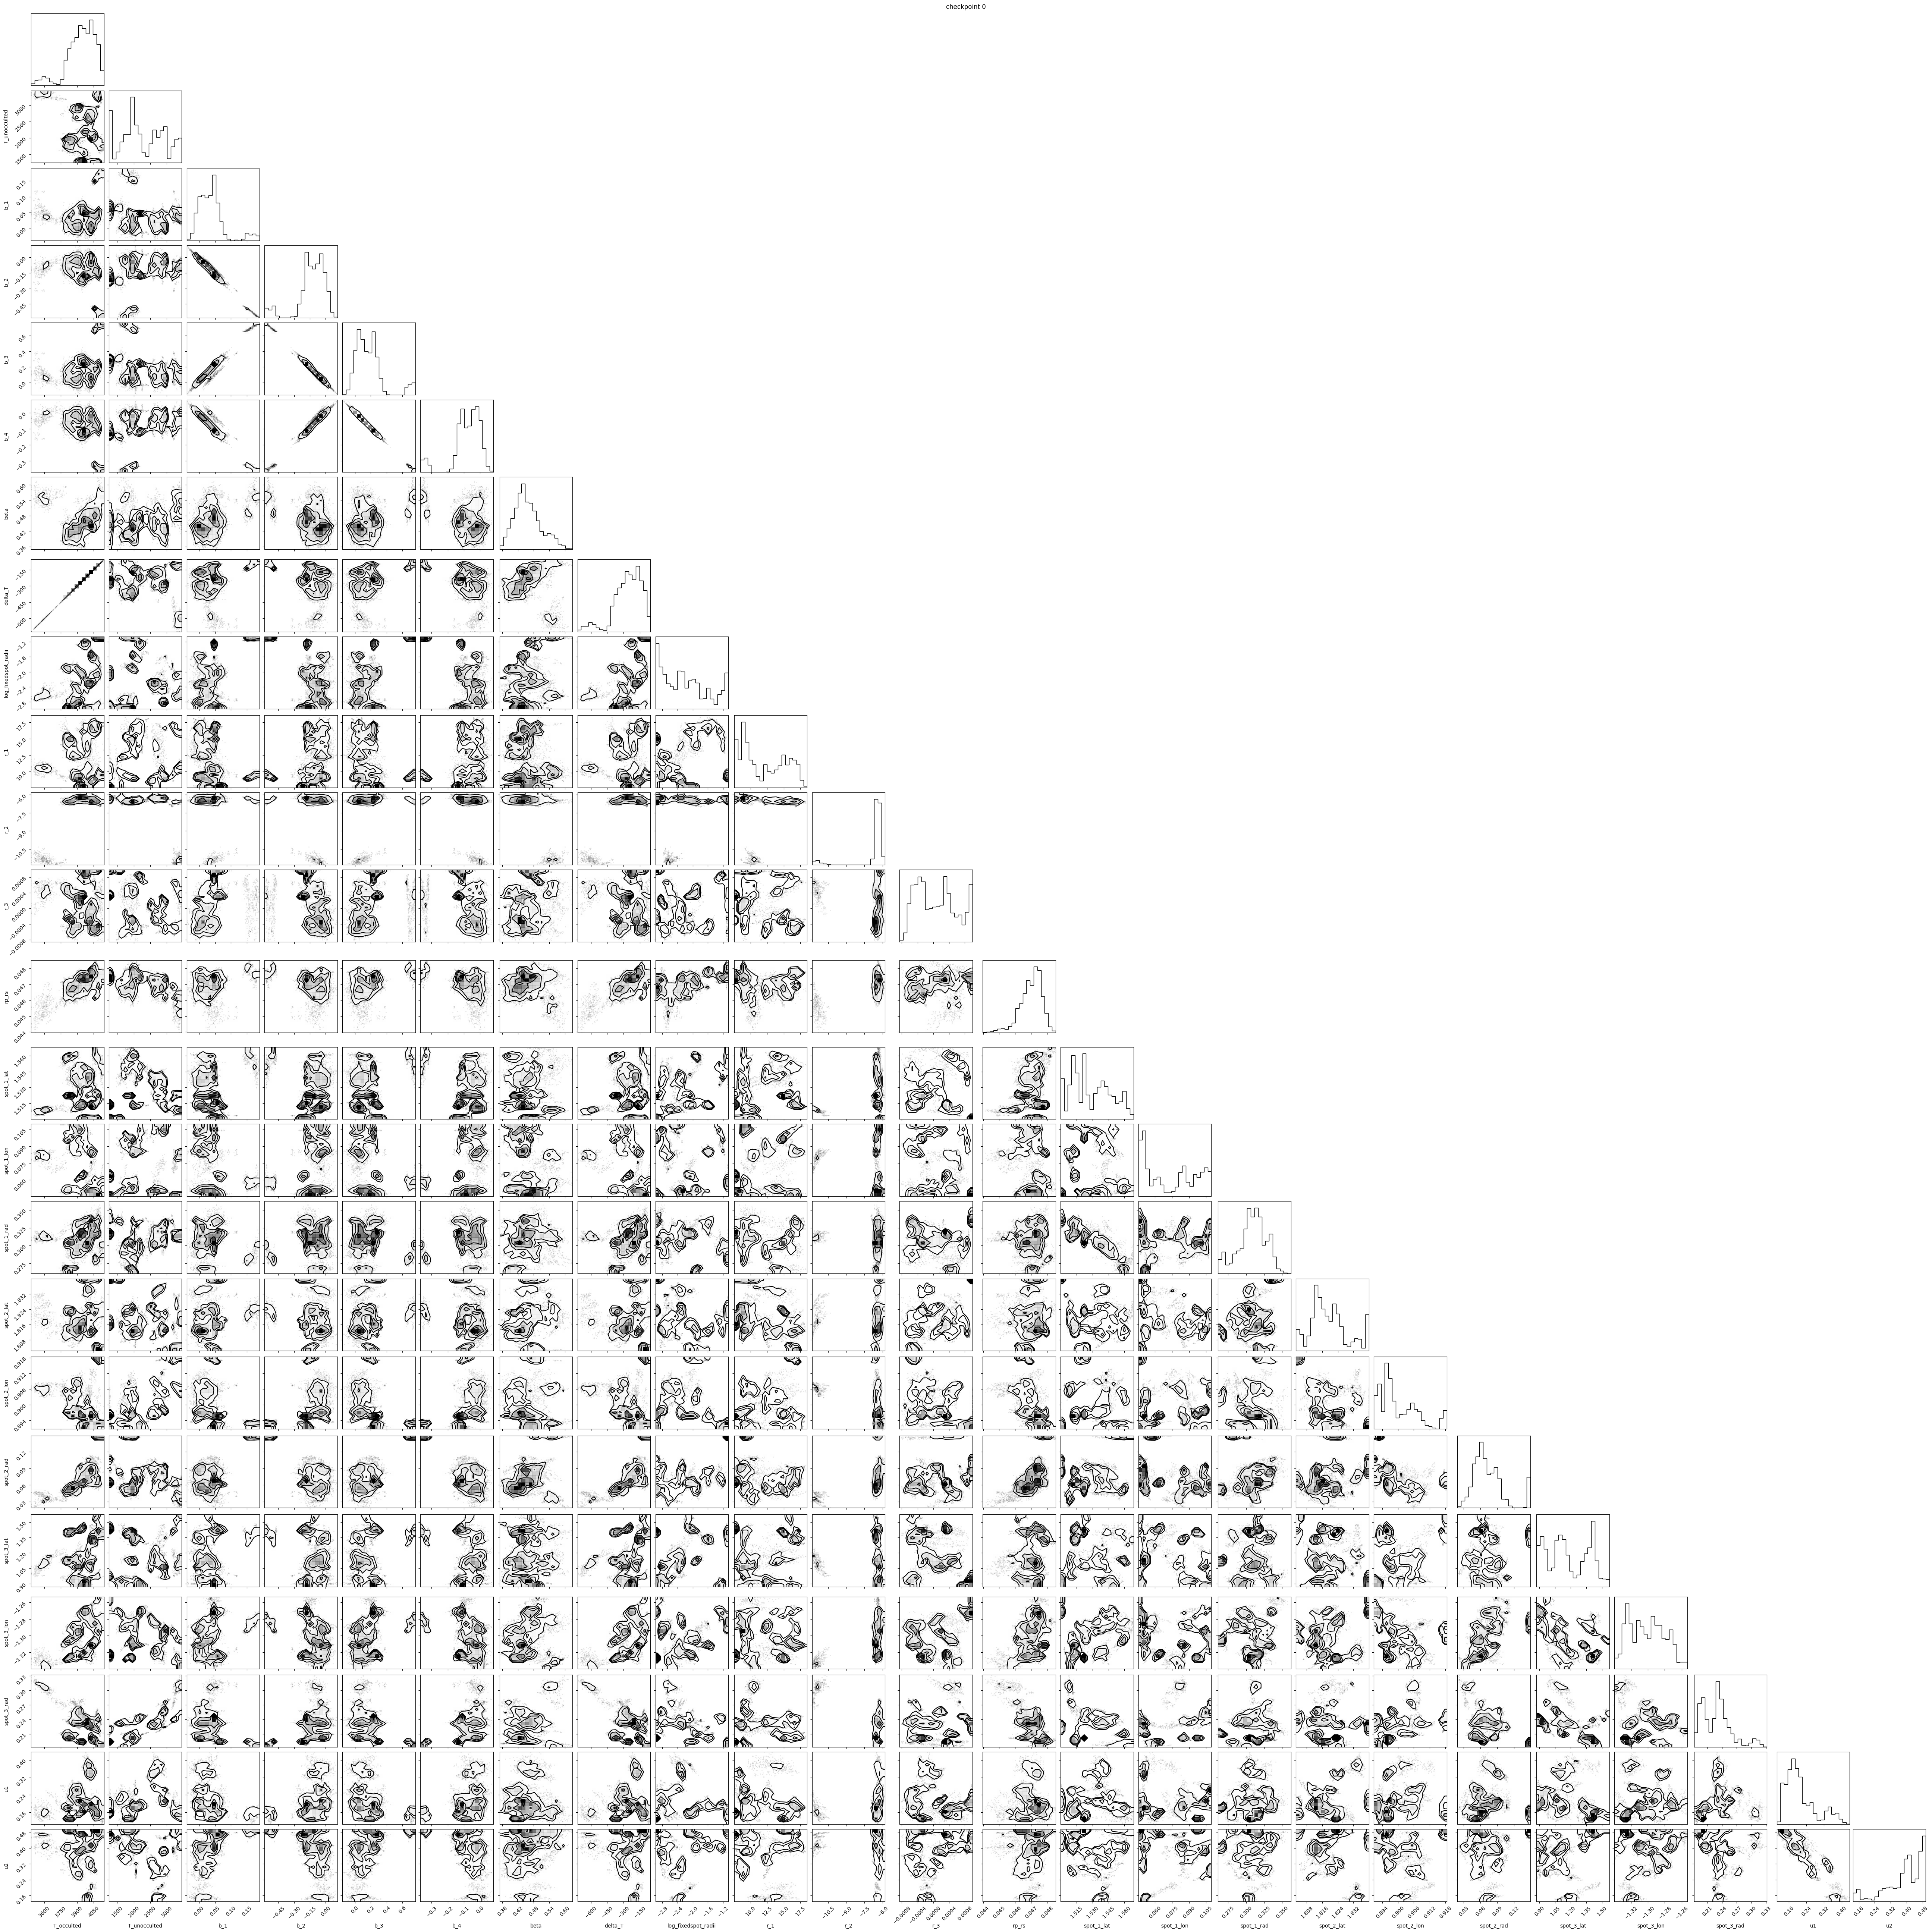

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

...

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

In [ ]:
rng_key = PRNGKey(10)

sampler = NUTS(
    numpyro_model,
    dense_mass=True)

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=5, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()                                                                        

# arviz converts a numpyro MCMC object to an `InferenceData` object based on xarray:
result = arviz.from_numpyro(mcmc)

In [ ]:
'Save the result'
result.to_netcdf(f'../data/samples/{model_designation}')

'Print the summary'
arviz.summary(result)

In [ ]:
'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo